In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df=pd.read_csv("Algerian_forest_fires_dataset.csv",header=1)

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')

In [5]:
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [7]:
cols = df.columns[:-1]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    float64
 1   month        244 non-null    float64
 2   year         244 non-null    float64
 3   Temperature  244 non-null    float64
 4    RH          244 non-null    float64
 5    Ws          244 non-null    float64
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      244 non-null    object 
dtypes: float64(13), object(1)
memory usage: 27.0+ KB


In [9]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1.0,6.0,2012.0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2.0,6.0,2012.0,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,3.0,6.0,2012.0,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4.0,6.0,2012.0,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,5.0,6.0,2012.0,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [10]:
df.columns=df.columns.str.strip()

In [11]:
df['Classes'] = df['Classes'].str.strip()   

In [12]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Classes       1
Name: count, dtype: int64

In [13]:
df['Classes'].unique()

array(['not fire', 'fire', nan, 'Classes'], dtype=object)

In [14]:
df=df[df['Classes']!='Classes']

In [15]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [16]:
df['Classes']=df['Classes'].map({'not fire':0,'fire':1})

In [17]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
241,26.0,9.0,2012.0,30.0,65.0,14.0,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1.0
242,27.0,9.0,2012.0,28.0,87.0,15.0,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0.0
243,28.0,9.0,2012.0,27.0,87.0,29.0,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0.0
244,29.0,9.0,2012.0,24.0,54.0,18.0,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0.0
245,30.0,9.0,2012.0,24.0,64.0,15.0,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0.0


In [18]:
df['Classes'].value_counts()

Classes
1.0    137
0.0    106
Name: count, dtype: int64

In [19]:
df.isnull().sum()

day            1
month          1
year           1
Temperature    1
RH             1
Ws             1
Rain           1
FFMC           1
DMC            1
DC             2
ISI            1
BUI            1
FWI            2
Classes        2
dtype: int64

In [20]:
from sklearn.impute import SimpleImputer

In [21]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy='mean')

num = df.iloc[:, :-1]

df.iloc[:, :-1] = num_imp.fit_transform(num)

In [22]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        2
dtype: int64

In [23]:
df['Classes'].unique()


array([ 0.,  1., nan])

In [24]:
df['Classes'].value_counts()

Classes
1.0    137
0.0    106
Name: count, dtype: int64

In [25]:
df['Classes'].unique()

array([ 0.,  1., nan])

In [26]:
df['Classes'] = df['Classes'].fillna(1.0)

In [27]:
stats.mode(df['Classes'])

ModeResult(mode=1.0, count=139)

In [28]:
df['Classes'].unique()

array([0., 1.])

<Axes: >

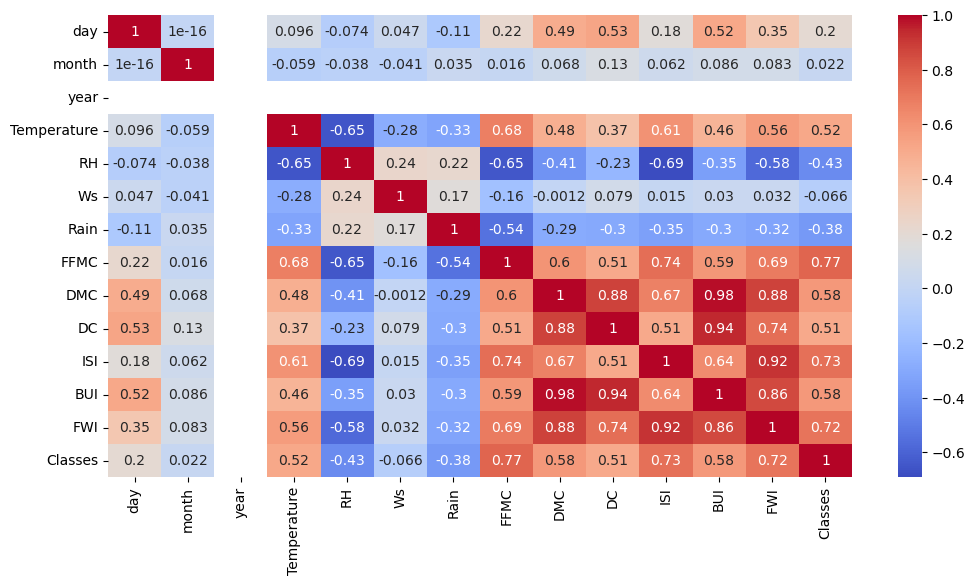

In [29]:
fig,axis=plt.subplots(figsize=(12,6))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

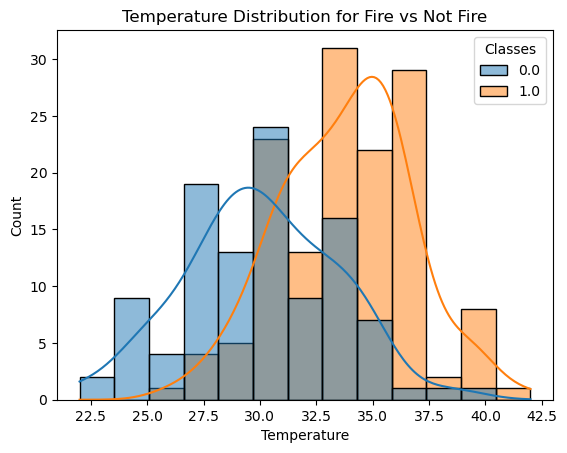

In [30]:
sns.histplot(data=df, x="Temperature", hue="Classes", kde=True)
plt.title("Temperature Distribution for Fire vs Not Fire")
plt.show()

In [31]:
df=df.drop(['day','month','year'],axis=1)

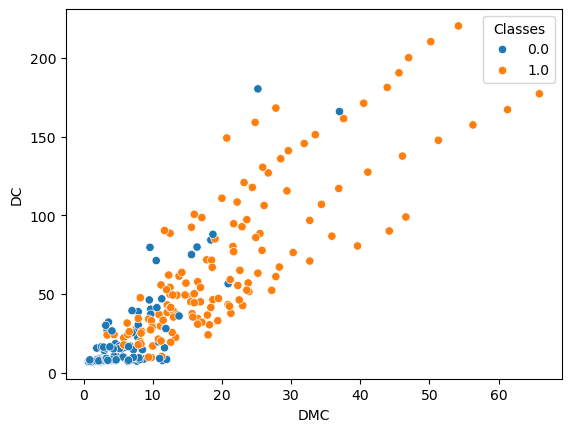

In [32]:
sns.scatterplot(data=df,x='DMC',y='DC',hue='Classes')
plt.show()

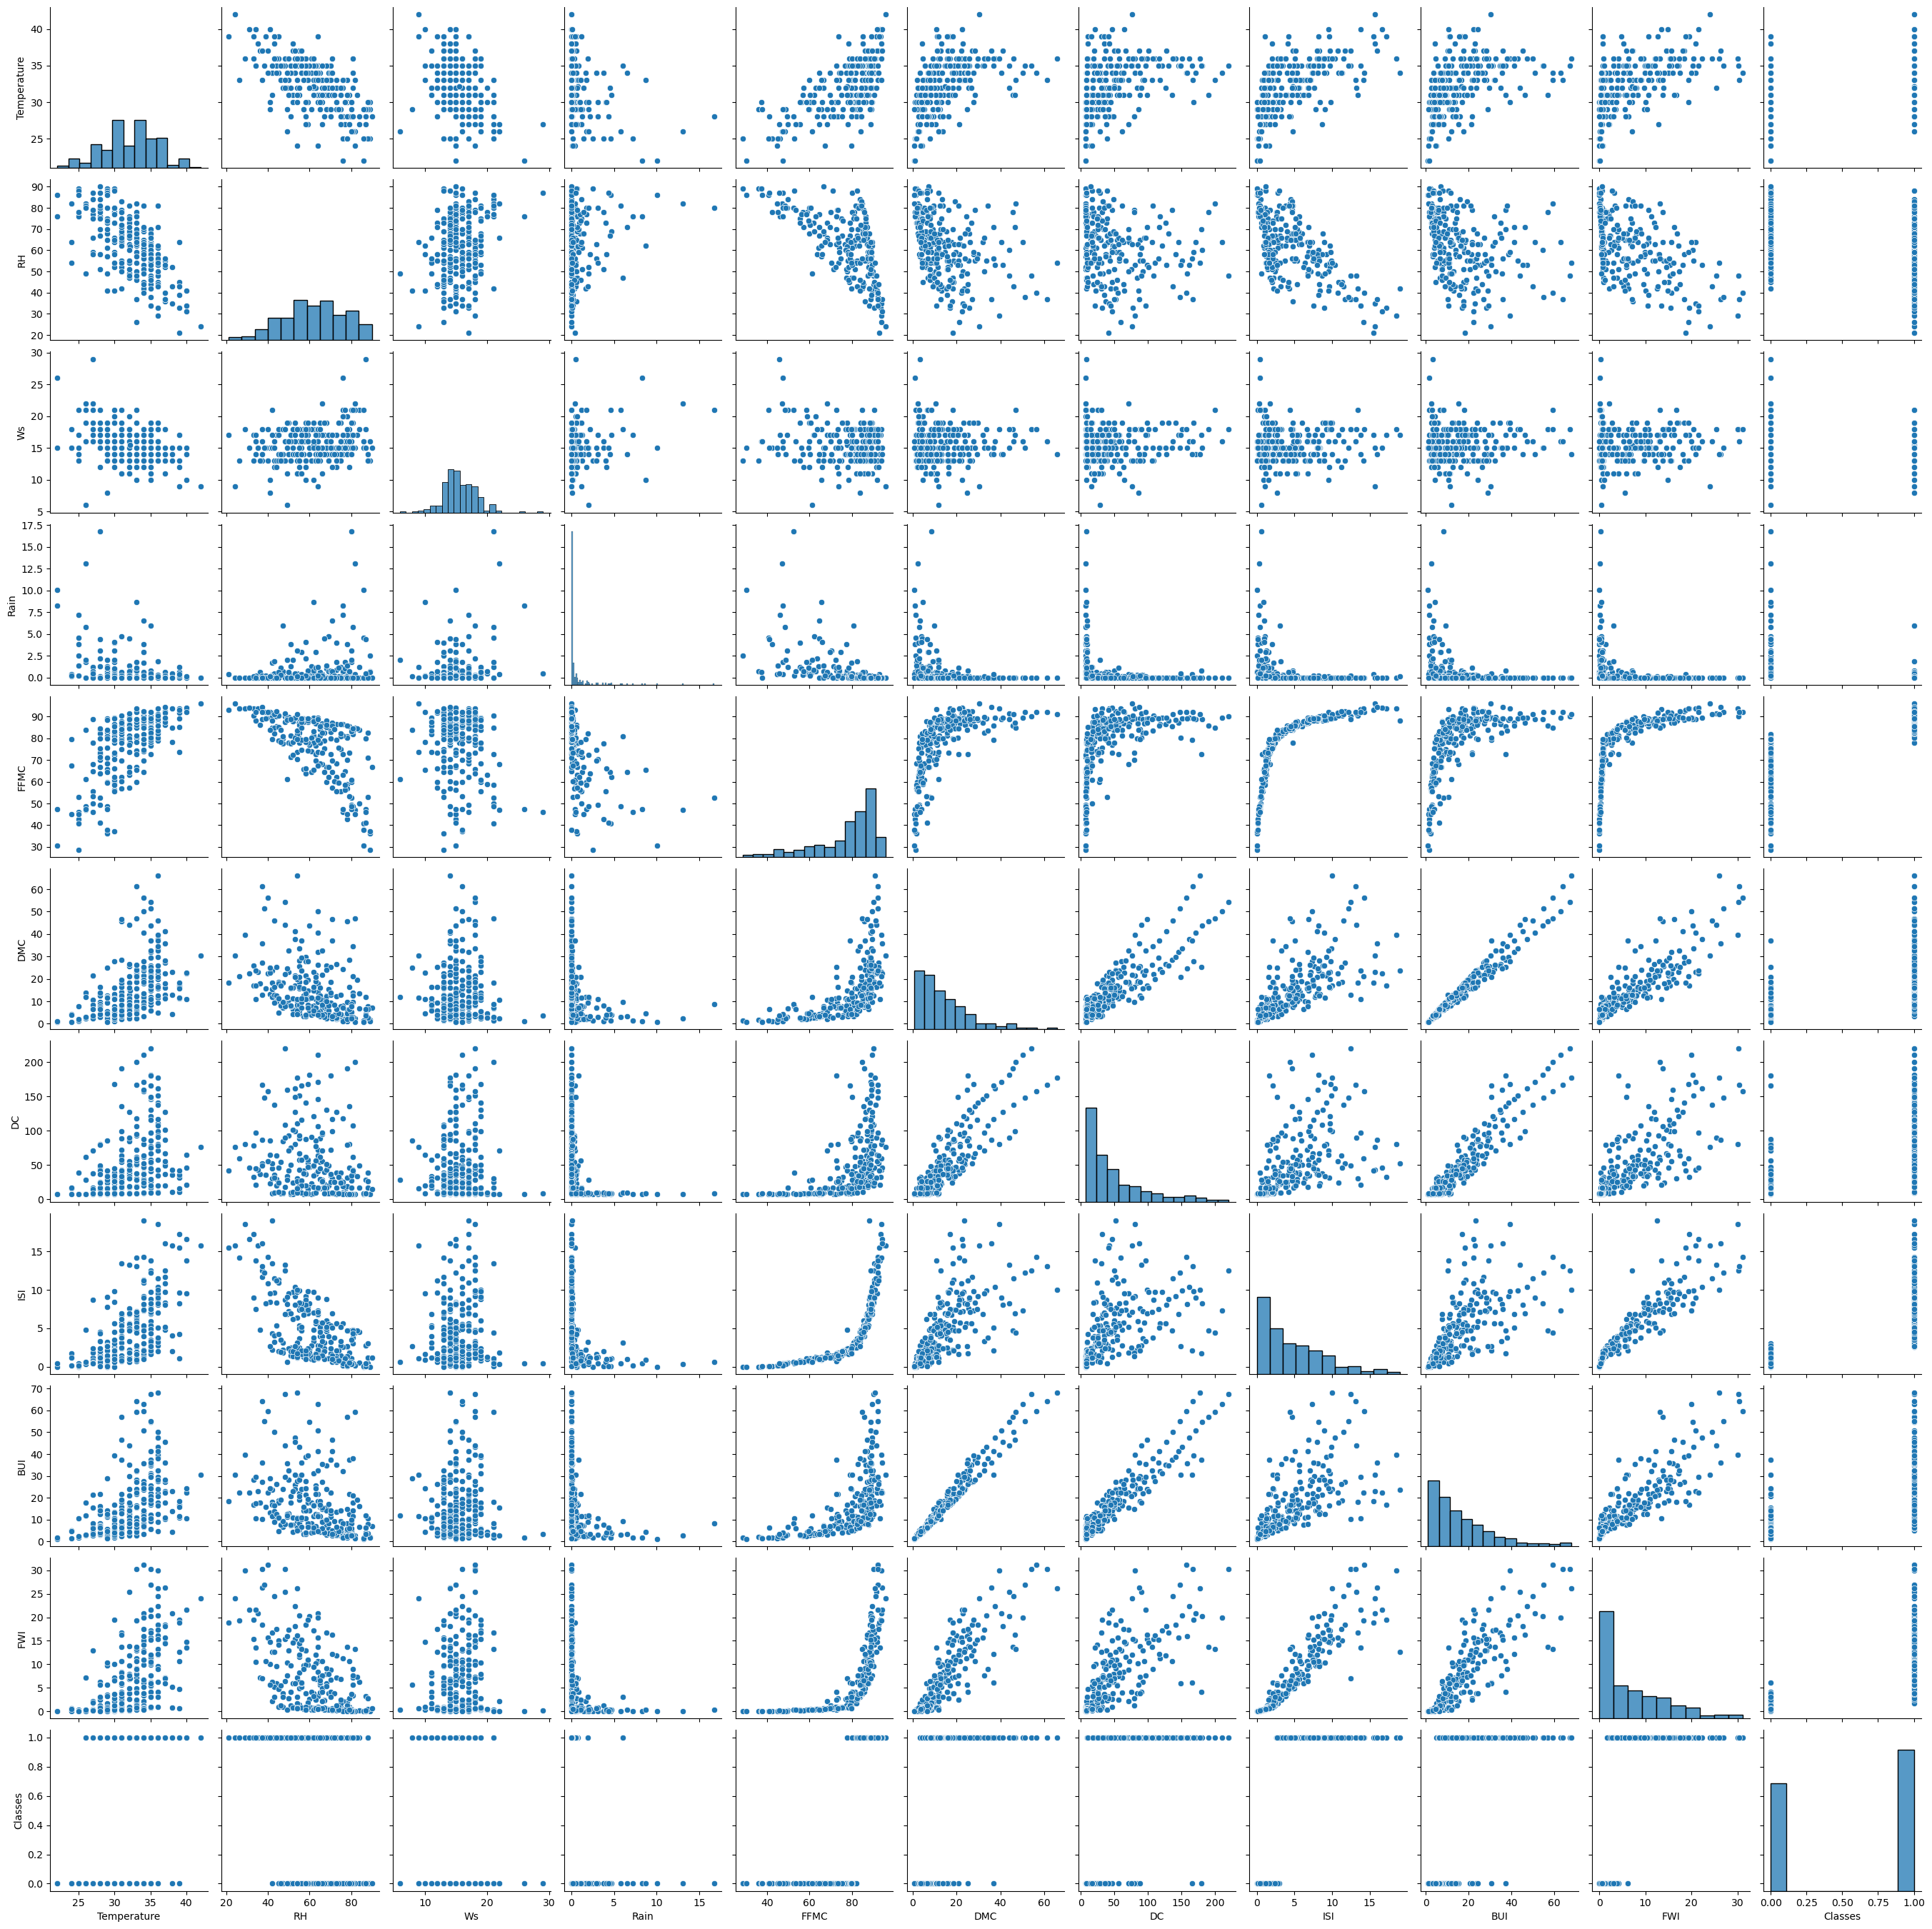

In [33]:
sns.pairplot(df)

<Axes: xlabel='Temperature', ylabel='RH'>

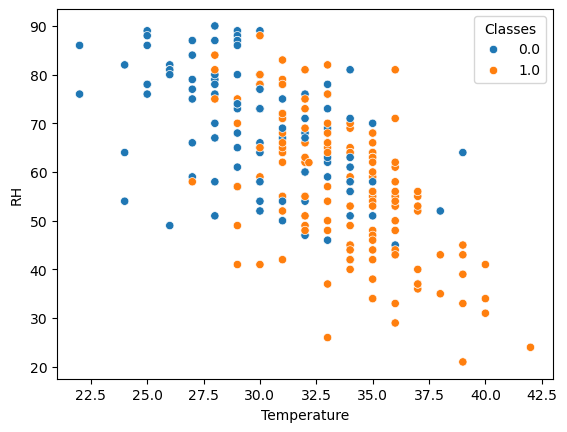

In [34]:
sns.scatterplot(x='Temperature',y='RH',data=df,hue='Classes')

In [35]:
#df['Temperature'].value_counts()

<Axes: >

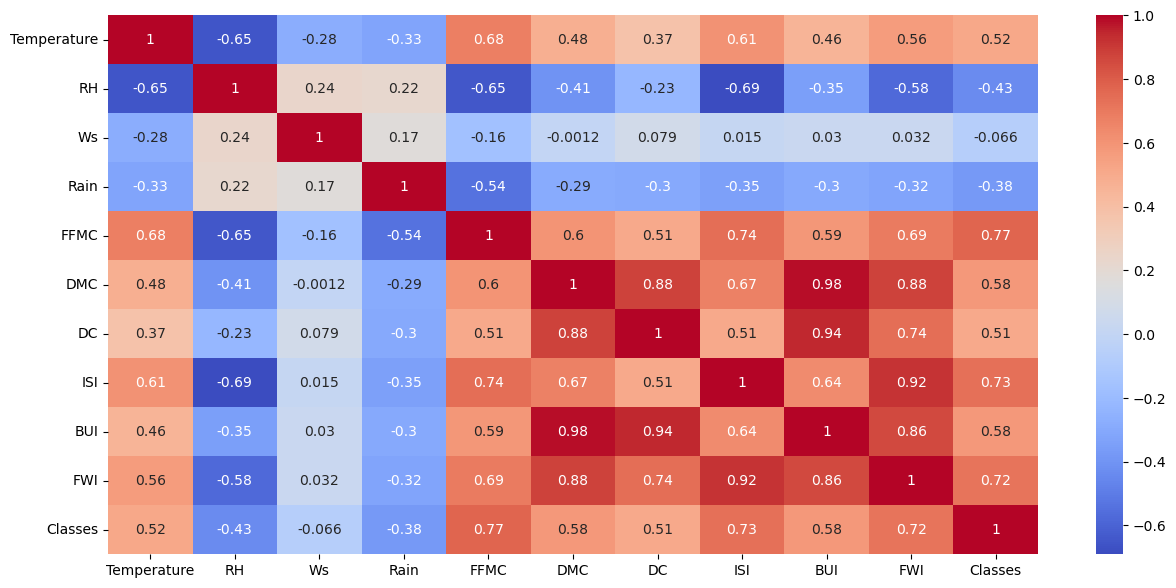

In [36]:
fig,axis=plt.subplots(figsize=(15,7))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [37]:
X = df[['Temperature','RH','FFMC','DMC','ISI']]
y = df['Classes']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,max_depth=6,random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        25
         1.0       1.00      1.00      1.00        24

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)


[[25  0]
 [ 0 24]]


In [43]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", acc)


Accuracy: 1.0


In [44]:
from sklearn.metrics import accuracy_score

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


In [45]:
from sklearn.metrics import accuracy_score

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 1.0


In [46]:
import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

       Feature  Importance
4          ISI    0.457815
2         FFMC    0.394826
3          DMC    0.106585
0  Temperature    0.030120
1           RH    0.010654


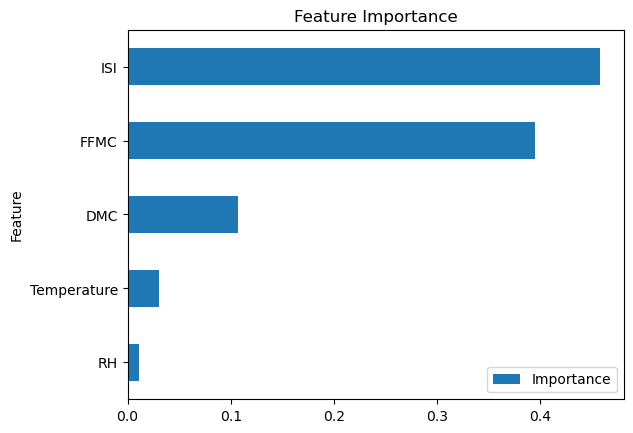

In [47]:
import matplotlib.pyplot as plt

feature_importance.sort_values(by="Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Feature Importance")
plt.show()

In [48]:
import joblib

joblib.dump(rf, "forest_fire_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [49]:
df.describe()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
count,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000,245.000000
mean,32.172131,61.938525,15.504098,0.760656,77.887705,14.673361,49.430864,4.774180,16.664754,7.035391,0.567347
std,3.626389,14.853668,2.804414,1.995304,14.308160,12.342668,47.469853,4.166753,14.175686,7.410011,0.496458
min,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,30.000000,52.000000,14.000000,0.000000,72.300000,5.800000,14.200000,1.400000,6.000000,0.700000,0.000000
50%,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.400000,3.500000,12.400000,4.700000,1.000000
75%,35.000000,73.000000,17.000000,0.500000,88.300000,20.700000,67.200000,7.300000,22.400000,11.300000,1.000000
max,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


## Cross-validation-->Check how well the model works on new data , so it doesn’t just memorize the training data.


In [50]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=100)
scores = cross_val_score(rf, X, y, cv=5)

print("Cross-validation accuracies:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation accuracies: [0.97959184 0.95918367 0.97959184 1.         1.        ]
Mean CV accuracy: 0.9836734693877551


In [51]:
X.columns

Index(['Temperature', 'RH', 'FFMC', 'DMC', 'ISI'], dtype='object')